# Decision Planner Comparison

Colab notebook for comparing seven decision planning strategies on a small CICIDS sample.

In [11]:
!pip install -q tensorflow pandas numpy scikit-learn matplotlib seaborn transformers


In [12]:
import os
import subprocess
import sys
from pathlib import Path

repo_path = Path('/content/AI_Agentic_DL')
branch_name = 'final-pipeline-integration'

if not repo_path.exists():
    !git clone https://github.com/Lawapaul/AI_Agentic_DL.git /content/AI_Agentic_DL

subprocess.run(['git', '-C', str(repo_path), 'fetch', 'origin'], check=True)
subprocess.run(['git', '-C', str(repo_path), 'checkout', branch_name], check=True)
subprocess.run(['git', '-C', str(repo_path), 'pull', 'origin', branch_name], check=True)

if str(repo_path) not in sys.path:
    sys.path.insert(0, str(repo_path))

%cd /content/AI_Agentic_DL
print('Repo path:', repo_path)
print('Branch:', branch_name)


/content/AI_Agentic_DL
Repo path: /content/AI_Agentic_DL
Branch: final-pipeline-integration


In [13]:
from google.colab import drive

drive.mount('/content/drive', force_remount=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import os
from pathlib import Path
import numpy as np

base_candidates = [
    Path('/content/drive/MyDrive/Deep Learning Project/AI Agentic'),
    Path('/content/drive/MyDrive/AI Agentic'),
    Path('/content/AI_Agentic_DL'),
]
base_path = next((path for path in base_candidates if path.exists()), None)
if base_path is None:
    raise FileNotFoundError(f'No project base found in: {base_candidates}')

processed_candidates = [
    base_path / 'data' / 'processed',
    Path('/content/AI_Agentic_DL/data/processed'),
]
required = ['X_test.npy', 'y_test.npy']
processed_path = next(
    (path for path in processed_candidates if path.exists() and all((path / name).exists() for name in required)),
    None,
)
if processed_path is None:
    raise FileNotFoundError(f'No processed dataset found in: {processed_candidates}')

X = np.load(processed_path / 'X_test.npy')[:20]
y = np.load(processed_path / 'y_test.npy')[:20]

if X.ndim == 3 and X.shape[-1] == 1:
    X_model = X.astype('float32')
else:
    X_model = X.reshape(X.shape[0], X.shape[1], 1).astype('float32')

X_flat = X_model.reshape(X_model.shape[0], -1)
print('Processed path:', processed_path)
print('X_model shape:', X_model.shape)
print('y shape:', y.shape)


Processed path: /content/drive/MyDrive/Deep Learning Project/AI Agentic/data/processed
X_model shape: (20, 78, 1)
y shape: (20,)


In [15]:
from models.trainer import IDSModelTrainer

model_candidates = [
    base_path / 'saved_models' / 'hybrid_cnn_lstm_full_2_2m.keras',
    base_path / 'saved_models' / 'hybrid_cnn_lstm_500k.keras',
    Path('/content/AI_Agentic_DL/saved_models/hybrid_cnn_lstm_full_2_2m.keras'),
    Path('/content/AI_Agentic_DL/saved_models/hybrid_cnn_lstm_500k.keras'),
]
model_path = next((path for path in model_candidates if path.exists()), None)
if model_path is None:
    raise FileNotFoundError(f'No pretrained hybrid model found in: {model_candidates}')

model = IDSModelTrainer.load_model(str(model_path))
print('Loaded model:', model_path)


Loading model from: /content/drive/MyDrive/Deep Learning Project/AI Agentic/saved_models/hybrid_cnn_lstm_full_2_2m.keras
Loaded model: /content/drive/MyDrive/Deep Learning Project/AI Agentic/saved_models/hybrid_cnn_lstm_full_2_2m.keras


In [16]:
import numpy as np

probs = model.predict(X_model, verbose=0)
preds = np.argmax(probs, axis=1)

print('Predictions shape:', preds.shape)
print('Probabilities shape:', probs.shape)


Predictions shape: (20,)
Probabilities shape: (20, 15)


In [17]:
from decision_planner.rule_based import RuleBasedPlanner
from decision_planner.confidence_based import ConfidenceBasedPlanner
from decision_planner.risk_based import RiskBasedPlanner
from decision_planner.hybrid import HybridPlanner
from decision_planner.rl_planner import RLPlanner
from decision_planner.llm_planner import LLMPlanner
from decision_planner.policy_based import PolicyBasedPlanner
from collections import Counter


In [18]:
def vote(actions):
    return Counter(actions).most_common(1)[0][0]

def clean_result(r):
    return {k: str(v) for k, v in r.items()}


In [19]:
def vote(actions):
    return Counter(actions).most_common(1)[0][0]

def clean_result(r):
    return {k: str(v) for k, v in r.items()}

In [20]:
attacks = ['Attack' if int(pred) != 0 else 'Normal Traffic' for pred in preds[:10]]
confidences = [float(max(prob)) for prob in probs[:10]]
severities = [
    'High' if conf > 0.8 else 'Medium' if conf > 0.6 else 'Low'
    for conf in confidences
]
targets = [
    'No Action' if attack == 'Normal Traffic' else 'Block' if conf > 0.85 else 'Alert' if conf > 0.6 else 'Monitor'
    for attack, conf in zip(attacks, confidences)
]

In [21]:
rule = RuleBasedPlanner().fit(attacks, confidences, targets)
conf = ConfidenceBasedPlanner().fit(confidences, targets)
risk = RiskBasedPlanner().fit(confidences, severities, targets)
hybrid = HybridPlanner().fit(attacks, confidences, severities, targets)
rl = RLPlanner().fit(attacks, confidences, targets, epochs=10)
llm = LLMPlanner().fit(attacks, confidences, severities, targets)
policy = PolicyBasedPlanner().fit(attacks, severities, targets)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [22]:
results = []

for i in range(10):
    attack = attacks[i]
    conf_score = confidences[i]
    severity = severities[i]

    rule_action = rule.decide(attack, conf_score, severity)
    conf_action = conf.decide(attack, conf_score, severity)
    risk_action = risk.decide(attack, conf_score, severity)
    hybrid_action = hybrid.decide(attack, conf_score, severity)
    rl_action = rl.decide(attack, conf_score, severity)
    llm_action = llm.decide(attack, conf_score, severity)
    policy_action = policy.decide(attack, conf_score, severity)
    final_action = vote([rule_action, rl_action, policy_action])

    results.append({
        'index': i,
        'attack': attack,
        'confidence': conf_score,
        'severity': severity,
        'target_action': targets[i],
        'rule': rule_action,
        'confidence_based': conf_action,
        'risk': risk_action,
        'hybrid': hybrid_action,
        'rl': rl_action,
        'llm': llm_action,
        'policy': policy_action,
        'final_action': final_action
    })

    print(results[-1])

results = [clean_result(r) for r in results]

{'index': 0, 'attack': 'Normal Traffic', 'confidence': 0.999997079372406, 'severity': 'High', 'target_action': 'No Action', 'rule': np.str_('No Action'), 'confidence_based': 'No Action', 'risk': 'No Action', 'hybrid': 'No Action', 'rl': 'No Action', 'llm': 'No Action', 'policy': np.str_('No Action'), 'final_action': np.str_('No Action')}
{'index': 1, 'attack': 'Normal Traffic', 'confidence': 0.9999881386756897, 'severity': 'High', 'target_action': 'No Action', 'rule': np.str_('No Action'), 'confidence_based': 'No Action', 'risk': 'No Action', 'hybrid': 'No Action', 'rl': 'No Action', 'llm': 'No Action', 'policy': np.str_('No Action'), 'final_action': np.str_('No Action')}
{'index': 2, 'attack': 'Normal Traffic', 'confidence': 0.999998152256012, 'severity': 'High', 'target_action': 'No Action', 'rule': np.str_('No Action'), 'confidence_based': 'No Action', 'risk': 'No Action', 'hybrid': 'No Action', 'rl': 'No Action', 'llm': 'No Action', 'policy': np.str_('No Action'), 'final_action': n

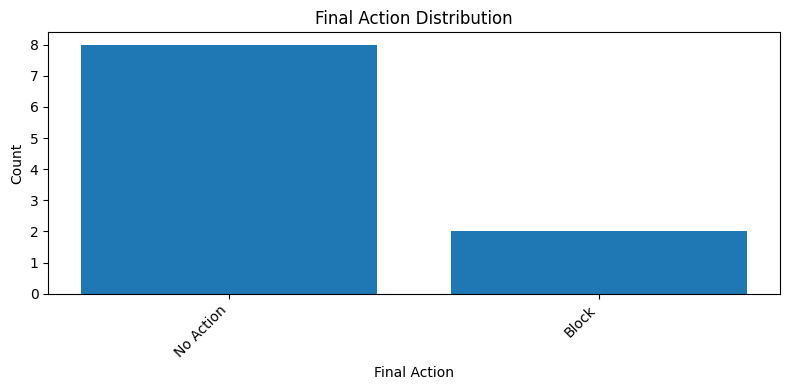

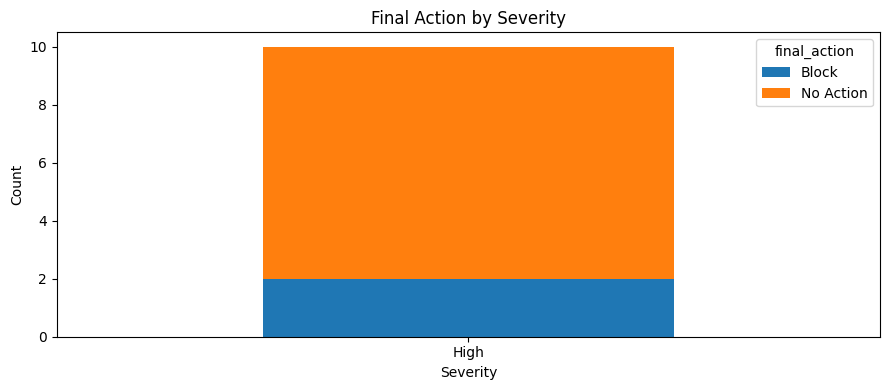

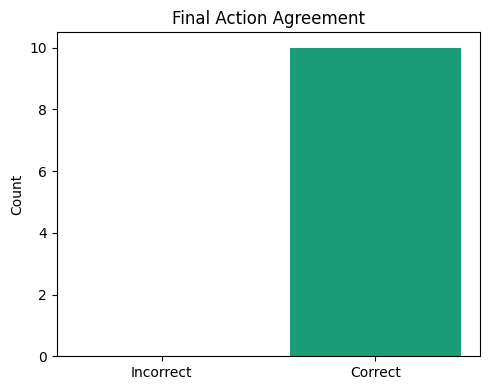

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Graphs for the decision-planner results ---
df = pd.DataFrame(results)

required_cols = {'final_action', 'target_action', 'severity'}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"results is missing required columns: {sorted(missing)}. Found: {sorted(df.columns)}")

# 1) Final decision distribution
fig, ax = plt.subplots(figsize=(8, 4))
final_counts = df['final_action'].value_counts().sort_values(ascending=False)
ax.bar(final_counts.index.astype(str), final_counts.values)
ax.set_title('Final Action Distribution')
ax.set_xlabel('Final Action')
ax.set_ylabel('Count')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2) Final decision split by severity
fig, ax = plt.subplots(figsize=(9, 4))
stacked = pd.crosstab(df['severity'].astype(str), df['final_action'].astype(str))
stacked = stacked.sort_index()
stacked.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Final Action by Severity')
ax.set_xlabel('Severity')
ax.set_ylabel('Count')
plt.setp(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# 3) Agreement vs target_action (correct vs incorrect)
df['is_correct'] = df['final_action'] == df['target_action']
fig, ax = plt.subplots(figsize=(5, 4))
correct_counts = df['is_correct'].value_counts().sort_index()
labels = ['Incorrect', 'Correct']
heights = [int(correct_counts.get(False, 0)), int(correct_counts.get(True, 0))]
ax.bar(labels, heights, color=['#d95f02', '#1b9e77'])
ax.set_title('Final Action Agreement')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [26]:
import json
from pathlib import Path

drive_candidates = [
    Path('/content/drive/MyDrive/Deep Learning Project/AI Agentic'),
    Path('/content/drive/MyDrive/AI Agentic'),
]

drive_base = next((path for path in drive_candidates if path.exists()), None)
if drive_base is None:
    raise FileNotFoundError(f'No Drive project folder found in: {drive_candidates}')

save_path = drive_base / 'experiments' / 'results'
save_path.mkdir(parents=True, exist_ok=True)

output_path = save_path / 'decision_planner_results.json'
with output_path.open('w', encoding='utf-8') as f:
    json.dump(results, f, indent=2)

print('Saved successfully to:', output_path)


Saved successfully to: /content/drive/MyDrive/Deep Learning Project/AI Agentic/experiments/results/decision_planner_results.json
